In [1]:
# 简洁版（宽表：每行一只股票，每列是日期），窗口=21，预测未来3天
# 依赖：pip install numpy pandas scikit-learn tensorflow
import re, math, numpy as np, pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

import builtins
min = builtins.min
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']

In [25]:
# ========= 可按需改动的超参数 =========
CSV_PATH = "../data/A_stock.csv"
ID_COL_CAND = ["code","ticker","symbol","ts_code","证券代码","股票代码"]
WINDOW = 21
HORIZON = 3
MODEL = "lstm"     # "lstm" 或 "gru"
EPOCHS = 120
BATCH_SIZE = 32
SEED = 42
# ====================================

In [26]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

def find_id_column(df):
    lower = {c.lower(): c for c in df.columns}
    for k in ID_COL_CAND:
        if k.lower() in lower: return lower[k.lower()]
    for c in df.columns:
        if re.search(r"(code|ticker|symbol|证券|股票)", c, re.I): return c
    raise ValueError("未找到股票代码列（如 code / ticker / symbol）。")

def is_date_col(name: str) -> bool:
    # 支持 "YYYY-MM-DD" 或 "MM-DD"/"M-D" 形式
    return bool(re.match(r"^\d{4}[-/]\d{1,2}[-/]\d{1,2}$", name)) or bool(re.match(r"^\d{1,2}[-/]\d{1,2}$", name))

def date_sort_key(name: str):
    if re.match(r"^\d{4}[-/]\d{1,2}[-/]\d{1,2}$", name):
        return pd.to_datetime(name, errors="coerce")
    m = re.match(r"^(\d{1,2})[-/](\d{1,2})$", name)
    if m:
        return (int(m.group(1)), int(m.group(2)))  # (月, 日)
    return name

# 1) 读取与列识别
df = pd.read_csv(CSV_PATH)
id_col = find_id_column(df)
date_cols = [c for c in df.columns if c != id_col and is_date_col(c)]
if not date_cols:
    # 兜底：选所有数值列当作“日期列”
    date_cols = [c for c in df.columns if c != id_col and pd.api.types.is_numeric_dtype(df[c])]
date_cols = sorted(date_cols, key=date_sort_key)

T = len(date_cols)
if T < WINDOW + HORIZON:
    raise RuntimeError(f"日期列数量不足：有 {T} 列，但需要 >= {WINDOW+HORIZON}。")

# 2) 按行（每只股票）构造滑窗样本（原始尺度，不做缩放）
X_raw, y_raw, sample_codes, tgt_idx = [], [], [], []
for _, row in df.iterrows():
    code = row[id_col]
    s = row[date_cols].astype(float).values
    s = pd.Series(s).fillna(method="ffill").fillna(method="bfill").values  # 行内缺失值补齐
    for i in range(T - WINDOW - HORIZON + 1):
        X_raw.append(s[i:i+WINDOW].reshape(WINDOW, 1))
        y_raw.append(s[i+WINDOW:i+WINDOW+HORIZON])
        sample_codes.append(code)
        tgt_idx.append((i+WINDOW, i+WINDOW+HORIZON))  # 目标对应的列区间

X_raw = np.array(X_raw)             # [N, 21, 1]
y_raw = np.array(y_raw)             # [N, 3]
N = len(X_raw)
if N == 0:
    raise RuntimeError("构不出任何样本，请检查窗口/步数或日期列数量。")

# 3) 简单按样本 8:2 划分（跨股票的样本混合；本数据每行通常只有 1 个样本）
n_train = int(N * 0.8)
idx = np.arange(N)
np.random.shuffle(idx)  # 打乱以免同一股票扎堆
train_idx, test_idx = idx[:n_train], idx[n_train:]

Xtr_raw, ytr_raw = X_raw[train_idx], y_raw[train_idx]
Xte_raw, yte_raw = X_raw[test_idx], y_raw[test_idx]
codes_test = [sample_codes[i] for i in test_idx]
tgt_idx_test = [tgt_idx[i] for i in test_idx]

# 4) 仅用训练集拟合 scaler，避免信息泄露
scaler = MinMaxScaler().fit(
    np.concatenate([Xtr_raw.reshape(-1,1), ytr_raw.reshape(-1,1)], axis=0)
)

def scale_xy(Xr, yr):
    Xs = scaler.transform(Xr.reshape(-1,1)).reshape(Xr.shape)
    ys = scaler.transform(yr.reshape(-1,1)).reshape(yr.shape)
    return Xs, ys

In [27]:
Xtr, ytr = scale_xy(Xtr_raw, ytr_raw)
Xte, yte = scale_xy(Xte_raw, yte_raw)

# 5) 简单模型（单层 LSTM/GRU + Dense 输出3步）
model = Sequential([
    (LSTM(64, input_shape=(WINDOW,1)) if MODEL.lower()=="lstm" else GRU(64, input_shape=(WINDOW,1))),
    Dense(HORIZON)
])
model.compile(optimizer="adam", loss="mse")
model.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, verbose=0)

# 6) 预测与反归一化
y_pred = model.predict(Xte, verbose=0)
def inv(a): return scaler.inverse_transform(a.reshape(-1,1)).reshape(a.shape)
y_true_inv = inv(yte)
y_pred_inv = inv(y_pred)

# 7) 误差（整体 + 分步）
overall_mae  = mean_absolute_error(y_true_inv.ravel(), y_pred_inv.ravel())
overall_rmse = math.sqrt(mean_squared_error(y_true_inv.ravel(), y_pred_inv.ravel()))
print(f"样本总数 N={N}，训练={len(train_idx)}，测试={len(test_idx)}，股票数={df.shape[0]}，日期列数={T}")
print(f"整体 MAE:  {overall_mae:.6f}")
print(f"整体 RMSE: {overall_rmse:.6f}")
for i in range(HORIZON):
    mae_i  = mean_absolute_error(y_true_inv[:,i], y_pred_inv[:,i])
    rmse_i = math.sqrt(mean_squared_error(y_true_inv[:,i], y_pred_inv[:,i]))
    print(f"t+{i+1}: MAE={mae_i:.6f} | RMSE={rmse_i:.6f}")

样本总数 N=5149，训练=4119，测试=1030，股票数=5149，日期列数=24
整体 MAE:  0.978104
整体 RMSE: 2.233334
t+1: MAE=0.913040 | RMSE=1.332888
t+2: MAE=0.903945 | RMSE=1.984217
t+3: MAE=1.117328 | RMSE=3.041322


In [28]:
# 8) 展示部分测试样本（股票代码 + 目标3天日期 + 真实/预测）
# show_k = min(5, len(codes_test))
show_k = builtins.min(5, len(codes_test))
print("\n测试集样本前几条（每行一只股票的一个窗口）：")
for j in range(show_k):
    code = codes_test[j]
    s, e = tgt_idx_test[j]  # [s, e)
    tgt_dates = date_cols[s:e]
    true_vals = np.round(y_true_inv[j], 6).tolist()
    pred_vals = np.round(y_pred_inv[j], 6).tolist()
    print(f"{j:02d}  code={code}  dates={tgt_dates}  True={true_vals}  Pred={pred_vals}")



测试集样本前几条（每行一只股票的一个窗口）：
00  code=sz.000852  dates=['07-30', '07-31', '08-01']  True=[7.1, 6.89, 6.89]  Pred=[6.168763160705566, 6.424901962280273, 6.272280216217041]
01  code=sz.000809  dates=['07-30', '07-31', '08-01']  True=[2.96, 2.91, 2.98]  Pred=[2.0857949256896973, 2.2725839614868164, 2.06557297706604]
02  code=sz.002515  dates=['07-30', '07-31', '08-01']  True=[6.38, 6.57, 6.72]  Pred=[5.586176872253418, 5.845920085906982, 5.622588157653809]
03  code=sz.002406  dates=['07-30', '07-31', '08-01']  True=[7.95, 8.3, 8.02]  Pred=[7.40217399597168, 7.699538230895996, 7.487750053405762]
04  code=sz.300204  dates=['07-30', '07-31', '08-01']  True=[47.03, 51.99, 52.07]  Pred=[48.34073257446289, 50.0239143371582, 49.62238311767578]


In [29]:
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import builtins
min = builtins.min

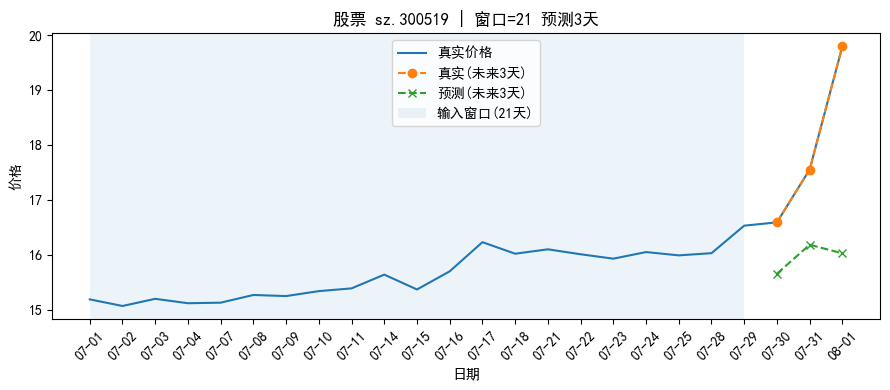

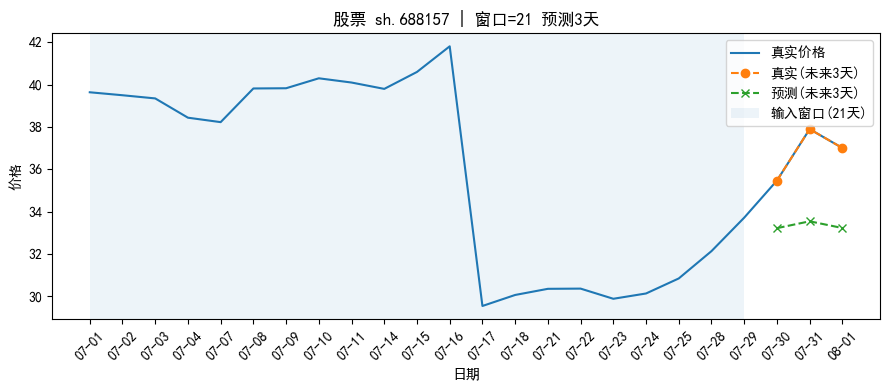

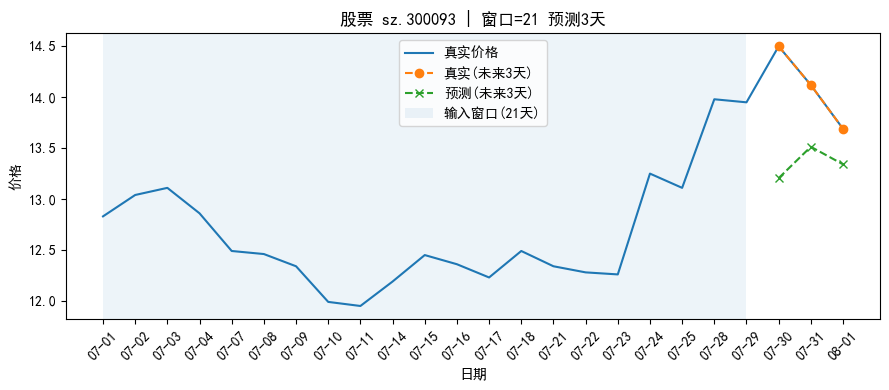

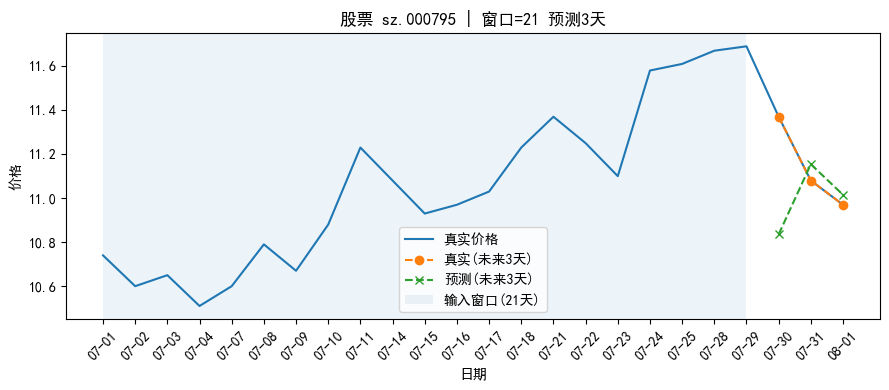

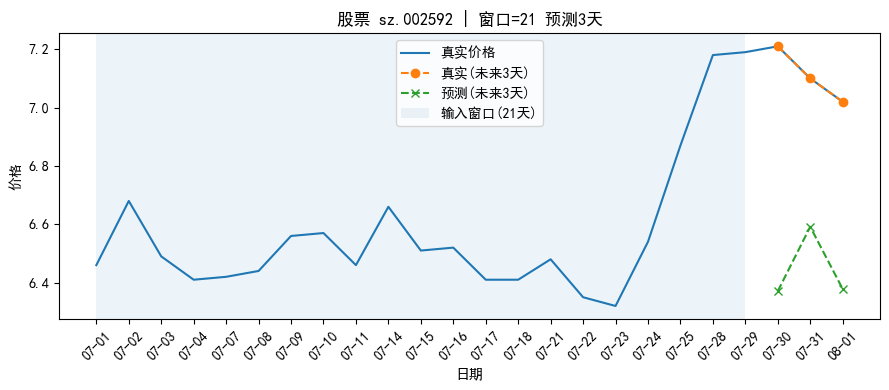

In [30]:
k = min(5, len(codes_test))
pick_indices = random.sample(range(len(codes_test)), k)


for j in pick_indices:
    code = codes_test[j]
    s, e = tgt_idx_test[j]  # 目标区间 [s, e)
    tgt_dates = date_cols[s:e]
    true_vals = y_true_inv[j]
    pred_vals = y_pred_inv[j]

    # 取该股票的全程真实价格
    row = df.loc[df[id_col] == code].iloc[0]
    series_vals = row[date_cols].astype(float).values
    series_vals = pd.Series(series_vals).fillna(method="ffill").fillna(method="bfill").values

    plt.figure(figsize=(9, 4))
    plt.plot(date_cols, series_vals, label="真实价格")
    plt.plot(tgt_dates, true_vals, linestyle="--", marker="o", label="真实(未来3天)")
    plt.plot(tgt_dates, pred_vals, linestyle="--", marker="x", label="预测(未来3天)")

    # 可选：标注输入窗口（前 21 天）
    win_start = s - WINDOW
    win_end = s
    if win_start >= 0:
        plt.axvspan(date_cols[win_start], date_cols[win_end - 1], alpha=0.08, label="输入窗口(21天)")

    plt.title(f"股票 {code} | 窗口={WINDOW} 预测{HORIZON}天")
    plt.xlabel("日期")
    plt.ylabel("价格")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
